# LLM Inference Optimization
## Quantization, KV-Cache, Batching, and Cost Analysis

This notebook covers optimization techniques for efficient LLM inference:
- Quantization (float32 → int8, int4)
- Memory savings calculation
- KV-cache simulation and reuse
- Speculative decoding concept
- Batching and throughput optimization
- Latency vs throughput tradeoff
- Model size and memory estimation
- Cost comparison of serving strategies

📺 **Video Lecture:** [https://youtu.be/W8YlpDD9kuA](https://youtu.be/W8YlpDD9kuA)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Quantization: Memory Savings

Demonstrate memory reduction from quantizing model weights.

Model: 7B parameters

Memory Usage by Quantization:
  float32     :   28.0 GB (reduction:   0.0%)
  float16     :   14.0 GB (reduction:  50.0%)
  int8        :    7.0 GB (reduction:  75.0%)
  int4        :    3.5 GB (reduction:  87.5%)


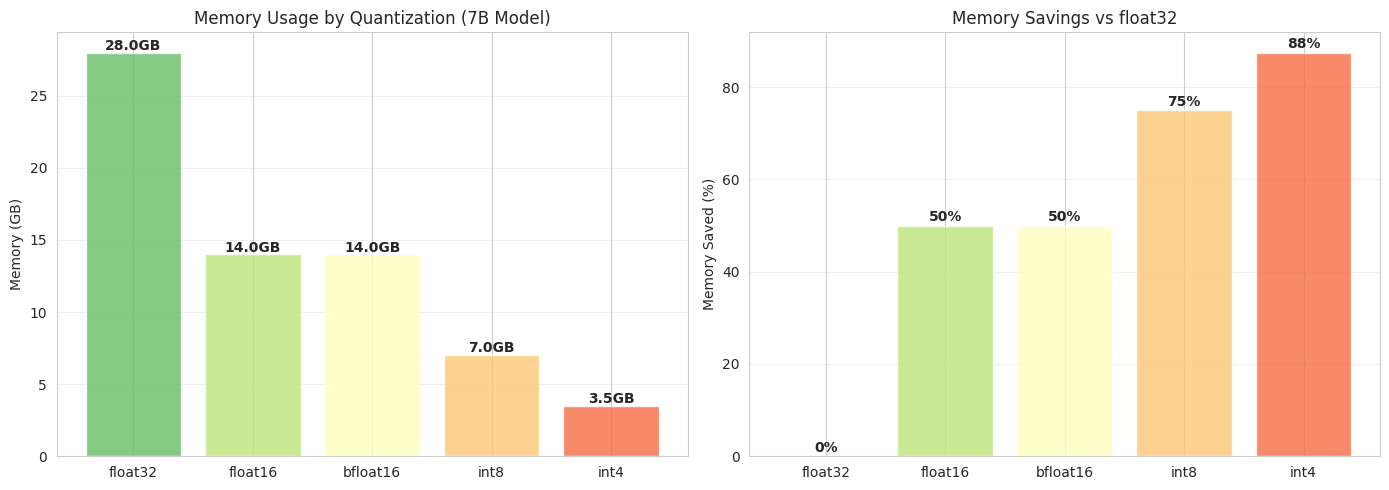

In [3]:
# Simulate a model with weights
model_params_billions = 7  # 7B parameter model
model_params = model_params_billions * 1e9

# Bytes per parameter
quantization_schemes = {
    'float32': 4,
    'float16': 2,
    'bfloat16': 2,
    'int8': 1,
    'int4': 0.5
}

# Calculate memory usage
memory_usage = {}
for scheme, bytes_per_param in quantization_schemes.items():
    total_bytes = model_params * bytes_per_param
    total_gb = total_bytes / 1e9
    memory_usage[scheme] = total_gb

print(f"Model: {model_params_billions}B parameters")
print(f"\nMemory Usage by Quantization:")
for scheme in ['float32', 'float16', 'int8', 'int4']:
    mb = memory_usage[scheme]
    reduction = (1 - mb / memory_usage['float32']) * 100
    print(f"  {scheme:12s}: {mb:6.1f} GB (reduction: {reduction:5.1f}%)")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
schemes = list(quantization_schemes.keys())
values = [memory_usage[s] for s in schemes]
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(schemes)))
ax1.bar(schemes, values, color=colors, alpha=0.8)
ax1.set_ylabel('Memory (GB)')
ax1.set_title(f'Memory Usage by Quantization ({model_params_billions}B Model)')
ax1.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(values):
    ax1.text(i, v + 0.2, f'{v:.1f}GB', ha='center', fontweight='bold')

# Memory savings
base_memory = memory_usage['float32']
savings = [(base_memory - memory_usage[s]) / base_memory * 100 for s in schemes]
ax2.bar(schemes, savings, color=colors, alpha=0.8)
ax2.set_ylabel('Memory Saved (%)')
ax2.set_title('Memory Savings vs float32')
ax2.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(savings):
    ax2.text(i, v + 1, f'{v:.0f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 2. KV-Cache Simulation

Demonstrate key-value cache for storing past tokens during generation.

KV-Cache Analysis:
  Hidden dim: 4096
  Layers: 32
  Max sequence: 2048
  Batch size: 1

KV-Cache Size:
  Per token: 0.02 MB
  Full cache: 1073.7 MB

Computation Savings:
  Without cache: O(n^2) - recompute K,V for all past tokens
  With cache: O(n) - reuse cached K,V


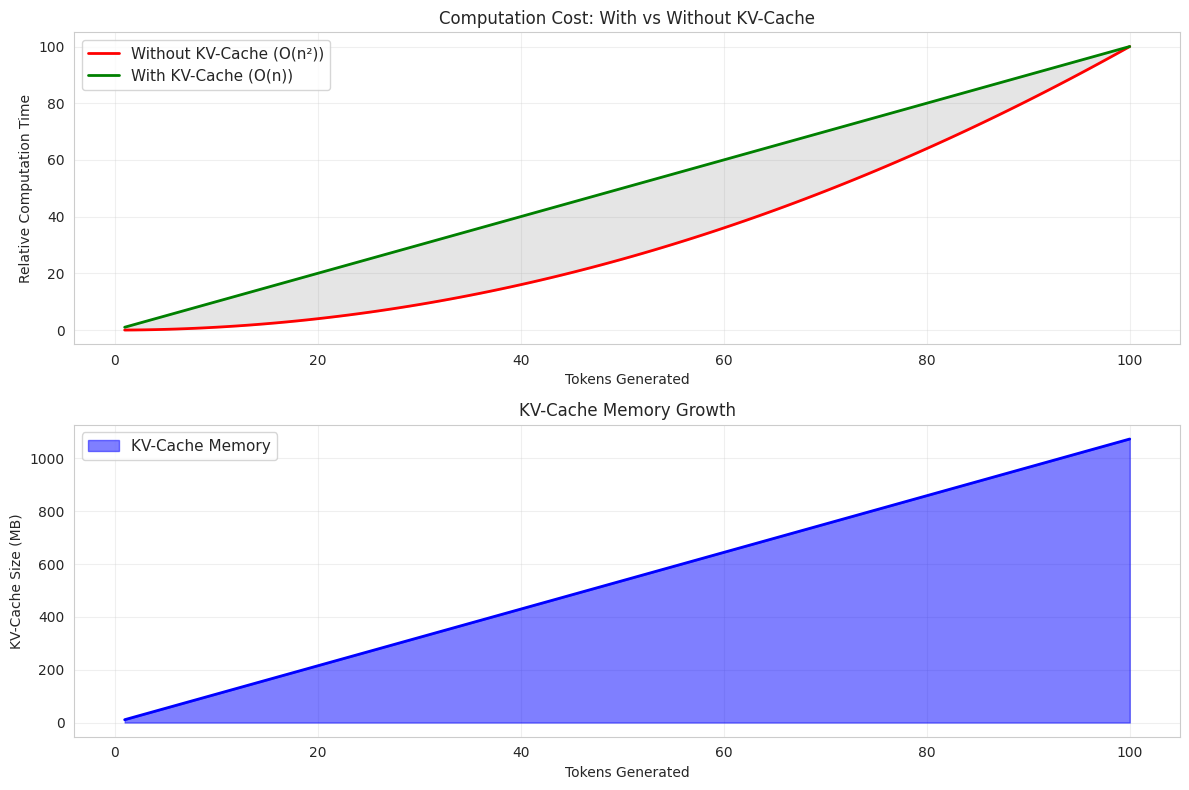

In [4]:
# Parameters
hidden_dim = 4096  # Hidden dimension
n_layers = 32  # Number of transformer layers
sequence_length = 2048  # Max sequence length
batch_size = 1

# KV-cache size per token (per batch, per layer)
bytes_per_float = 2  # Using float16
kv_per_token_per_layer = 2 * hidden_dim * bytes_per_float  # 2 for K and V

# Total KV-cache size
kv_cache_full = kv_per_token_per_layer * n_layers * sequence_length * batch_size / 1e6  # MB

# Simulate generation without and with caching
print(f"KV-Cache Analysis:")
print(f"  Hidden dim: {hidden_dim}")
print(f"  Layers: {n_layers}")
print(f"  Max sequence: {sequence_length}")
print(f"  Batch size: {batch_size}")
print(f"\nKV-Cache Size:")
print(f"  Per token: {kv_per_token_per_layer / 1e6:.2f} MB")
print(f"  Full cache: {kv_cache_full:.1f} MB")

# Compute savings (without cache, must recompute K,V for all past tokens)
print(f"\nComputation Savings:")
print(f"  Without cache: O(n^2) - recompute K,V for all past tokens")
print(f"  With cache: O(n) - reuse cached K,V")

# Illustrate token generation timeline
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Generation timeline
tokens_generated = np.arange(1, 101)
compute_time_no_cache = tokens_generated ** 2 / 100  # O(n^2)
compute_time_with_cache = tokens_generated  # O(n)

ax1.plot(tokens_generated, compute_time_no_cache, label='Without KV-Cache (O(n²))', linewidth=2, color='red')
ax1.plot(tokens_generated, compute_time_with_cache, label='With KV-Cache (O(n))', linewidth=2, color='green')
ax1.fill_between(tokens_generated, compute_time_with_cache, compute_time_no_cache, alpha=0.2, color='gray')
ax1.set_xlabel('Tokens Generated')
ax1.set_ylabel('Relative Computation Time')
ax1.set_title('Computation Cost: With vs Without KV-Cache')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Memory usage over sequence
kv_memory = np.arange(1, 101) * (kv_cache_full / 100)
ax2.fill_between(tokens_generated, kv_memory, alpha=0.5, color='blue', label='KV-Cache Memory')
ax2.plot(tokens_generated, kv_memory, linewidth=2, color='blue')
ax2.set_xlabel('Tokens Generated')
ax2.set_ylabel('KV-Cache Size (MB)')
ax2.set_title('KV-Cache Memory Growth')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Speculative Decoding Concept

Use a small draft model to generate candidates, verify with large model.

Speculative Decoding Analysis:
  Target tokens: 100
  Speculative depth (k): 4
  Draft model latency: 5 ms/token
  Large model latency: 50 ms/token
  Acceptance rate: 70%

Decoding Time:
  Autoregressive: 5000 ms
  Speculative: 2520 ms
  Speedup: 1.98x


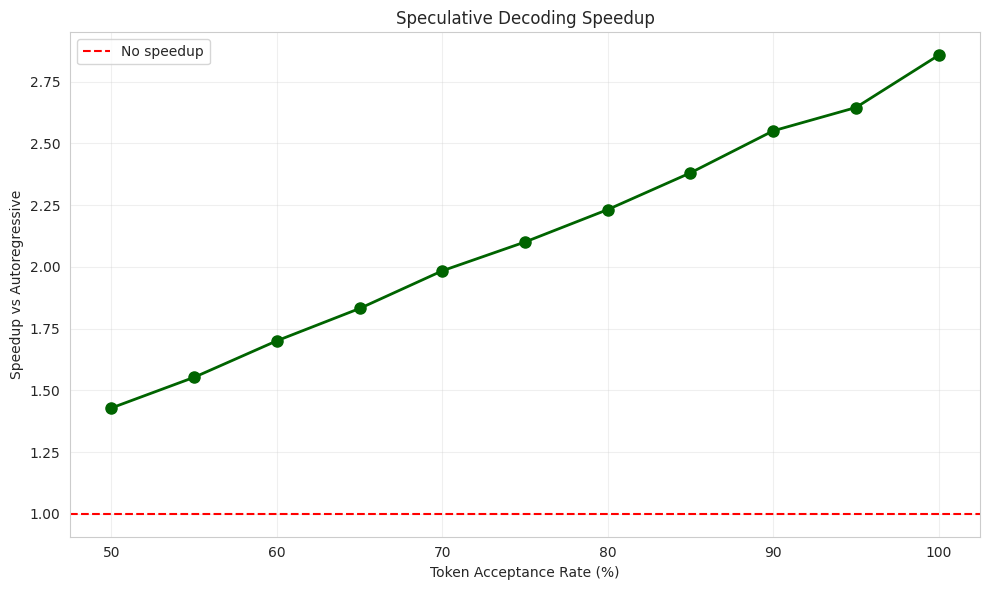

In [5]:
# Simulate speculative decoding
# Draft model generates k tokens, then verify with large model

# Model latencies (ms per token)
draft_model_latency = 5  # Fast small model
large_model_latency = 50  # Slow large model
k_spec = 4  # Generate 4 tokens speculatively

# Verification success rate (draft matches large model)
acceptance_rate = 0.7  # 70% of speculative tokens accepted

# Scenario 1: Autoregressive decoding (no speculation)
tokens_to_generate = 100
time_autoregressive = tokens_to_generate * large_model_latency

# Scenario 2: Speculative decoding
# For each group of k tokens:
# - Draft generates k tokens: k * draft_latency
# - Large model verifies: 1 * large_model_latency (can be parallelized)
# - Average accepted tokens per group: k * acceptance_rate

groups = np.ceil(tokens_to_generate / (k_spec * acceptance_rate))
time_speculative = groups * (k_spec * draft_model_latency + large_model_latency)

print(f"Speculative Decoding Analysis:")
print(f"  Target tokens: {tokens_to_generate}")
print(f"  Speculative depth (k): {k_spec}")
print(f"  Draft model latency: {draft_model_latency} ms/token")
print(f"  Large model latency: {large_model_latency} ms/token")
print(f"  Acceptance rate: {acceptance_rate:.0%}")
print(f"\nDecoding Time:")
print(f"  Autoregressive: {time_autoregressive:.0f} ms")
print(f"  Speculative: {time_speculative:.0f} ms")
print(f"  Speedup: {time_autoregressive / time_speculative:.2f}x")

# Speedup analysis with different acceptance rates
acceptance_rates = np.linspace(0.5, 1.0, 11)
speedups = []

for acc_rate in acceptance_rates:
    groups_temp = np.ceil(tokens_to_generate / (k_spec * acc_rate))
    time_spec_temp = groups_temp * (k_spec * draft_model_latency + large_model_latency)
    speedup = time_autoregressive / time_spec_temp
    speedups.append(speedup)

plt.figure(figsize=(10, 6))
plt.plot(acceptance_rates * 100, speedups, marker='o', linewidth=2, markersize=8, color='darkgreen')
plt.axhline(y=1, color='red', linestyle='--', label='No speedup')
plt.xlabel('Token Acceptance Rate (%)')
plt.ylabel('Speedup vs Autoregressive')
plt.title('Speculative Decoding Speedup')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Batching and Throughput

Show how batching size affects total throughput.

Batching Analysis:

Batch Size   Latency (ms)    GPU Util     Throughput     
------------------------------------------------------
1            12.0            4.6%         83             
2            14.0            9.0%         143            
4            18.0            17.2%        222            
8            26.0            31.3%        308            
16           42.0            52.3%        381            
32           74.0            75.8%        432            
64           138.0           91.1%        464            
128          266.0           94.8%        481            


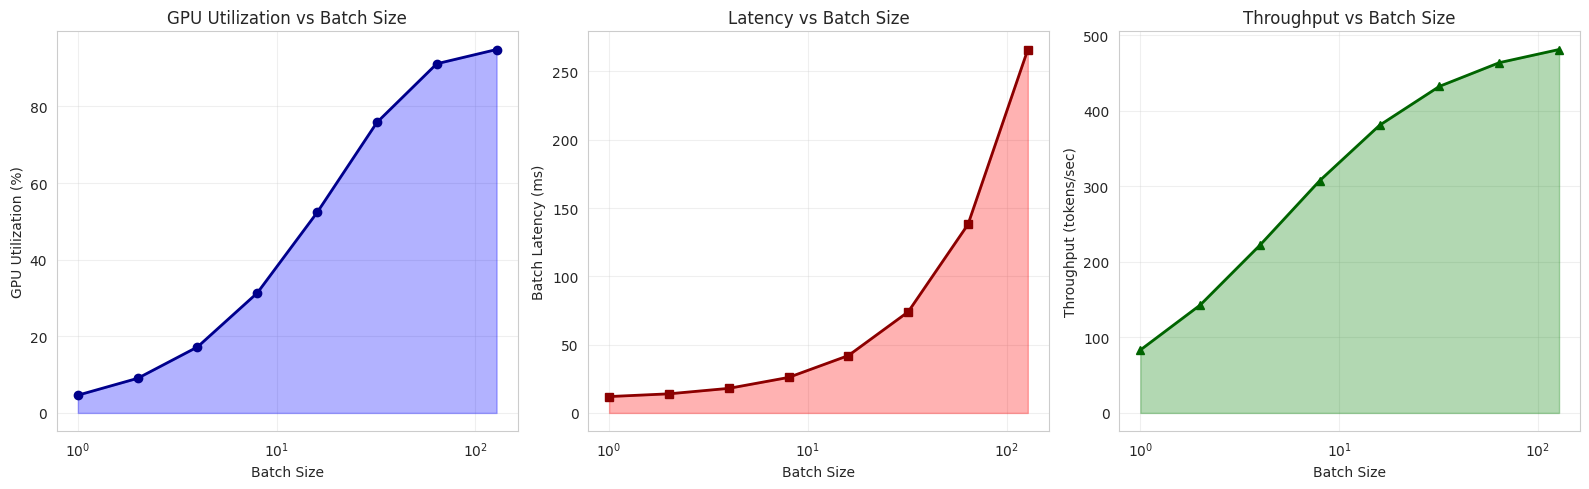

In [6]:
# Batching analysis
batch_sizes = np.array([1, 2, 4, 8, 16, 32, 64, 128])

# GPU utilization increases with batch size (asymptotically approaches max)
max_utilization = 0.95
gpu_util = 1 - np.exp(-0.05 * batch_sizes)  # Sigmoid-like curve
gpu_util = gpu_util * max_utilization

# Latency per batch (mostly fixed overhead + linear in batch size)
base_latency = 10  # ms
latency_per_sample = 2  # ms
total_latency = base_latency + batch_sizes * latency_per_sample

# Throughput = batch_size / total_latency (samples/ms = samples/second * 1000)
throughput = batch_sizes / total_latency * 1000  # tokens/second

print(f"Batching Analysis:")
print(f"\n{'Batch Size':<12} {'Latency (ms)':<15} {'GPU Util':<12} {'Throughput':<15}")
print("-" * 54)
for bs, lat, util, tp in zip(batch_sizes, total_latency, gpu_util, throughput):
    print(f"{bs:<12} {lat:<15.1f} {util:<12.1%} {tp:<15.0f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# GPU Utilization
axes[0].plot(batch_sizes, gpu_util * 100, marker='o', linewidth=2, color='darkblue')
axes[0].fill_between(batch_sizes, 0, gpu_util * 100, alpha=0.3, color='blue')
axes[0].set_xlabel('Batch Size')
axes[0].set_ylabel('GPU Utilization (%)')
axes[0].set_title('GPU Utilization vs Batch Size')
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')

# Latency
axes[1].plot(batch_sizes, total_latency, marker='s', linewidth=2, color='darkred')
axes[1].fill_between(batch_sizes, 0, total_latency, alpha=0.3, color='red')
axes[1].set_xlabel('Batch Size')
axes[1].set_ylabel('Batch Latency (ms)')
axes[1].set_title('Latency vs Batch Size')
axes[1].grid(True, alpha=0.3)
axes[1].set_xscale('log')

# Throughput
axes[2].plot(batch_sizes, throughput, marker='^', linewidth=2, color='darkgreen')
axes[2].fill_between(batch_sizes, 0, throughput, alpha=0.3, color='green')
axes[2].set_xlabel('Batch Size')
axes[2].set_ylabel('Throughput (tokens/sec)')
axes[2].set_title('Throughput vs Batch Size')
axes[2].grid(True, alpha=0.3)
axes[2].set_xscale('log')

plt.tight_layout()
plt.show()

## 5. Latency vs Throughput Tradeoff

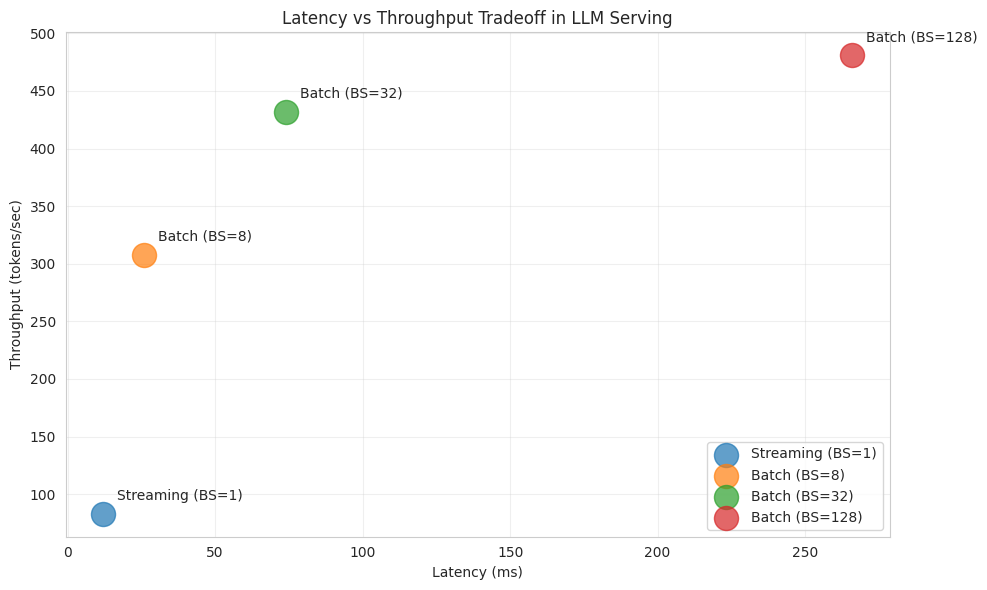


Serving Strategy Recommendations:
  Streaming (BS=1): Best for interactive/real-time applications
  Batch (BS=8-32): Balance between latency and throughput
  Batch (BS=128+): Maximum throughput for batch processing


In [7]:
# Different serving strategies
strategies = {
    'Streaming (BS=1)': {'batch_size': 1, 'latency': 12, 'throughput': 83},
    'Batch (BS=8)': {'batch_size': 8, 'latency': 26, 'throughput': 308},
    'Batch (BS=32)': {'batch_size': 32, 'latency': 74, 'throughput': 432},
    'Batch (BS=128)': {'batch_size': 128, 'latency': 266, 'throughput': 481}
}

# Plot tradeoff
plt.figure(figsize=(10, 6))
for strategy, metrics in strategies.items():
    plt.scatter(metrics['latency'], metrics['throughput'], s=300, alpha=0.7, label=strategy)
    plt.annotate(strategy, (metrics['latency'], metrics['throughput']), 
                xytext=(10, 10), textcoords='offset points', fontsize=10)

plt.xlabel('Latency (ms)')
plt.ylabel('Throughput (tokens/sec)')
plt.title('Latency vs Throughput Tradeoff in LLM Serving')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\nServing Strategy Recommendations:")
print("  Streaming (BS=1): Best for interactive/real-time applications")
print("  Batch (BS=8-32): Balance between latency and throughput")
print("  Batch (BS=128+): Maximum throughput for batch processing")

## 6. Model Size and Memory Estimation Calculator


Memory Requirements Estimation (Inference):
Model  float32 (GB)  float16 (GB)  int8 (GB)  int4 (GB)
   3B          30.0          24.0       21.0       19.5
   7B          70.0          56.0       49.0       45.5
  13B         130.0         104.0       91.0       84.5
  30B         300.0         240.0      210.0      195.0
  70B         700.0         560.0      490.0      455.0
 405B        4050.0        3240.0     2835.0     2632.5


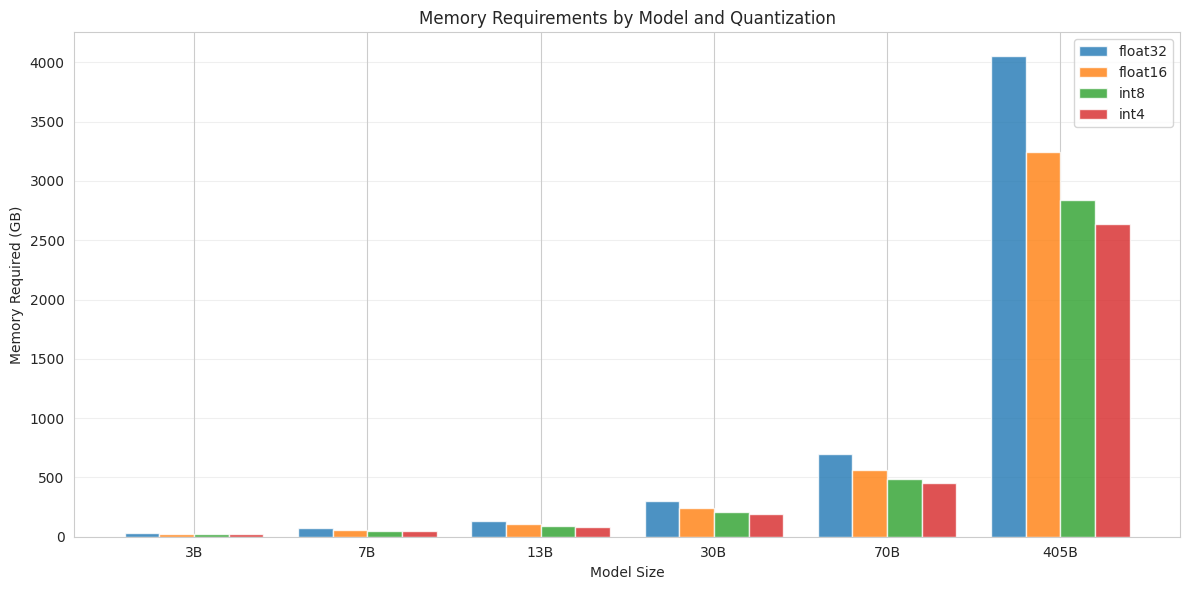

In [8]:
# Calculate memory requirements for different model sizes
model_sizes_b = [3, 7, 13, 30, 70, 405]  # Model sizes in billions

def estimate_memory_requirements(params_billions, dtype='float16'):
    """
    Estimate memory requirements for model inference.
    """
    bytes_per_param = {'float32': 4, 'float16': 2, 'int8': 1, 'int4': 0.5}
    bytes_pref = bytes_per_param.get(dtype, 2)
    
    params = params_billions * 1e9
    
    # Model weights
    model_mem = params * bytes_pref / 1e9  # GB
    
    # Activation memory (batch_size=1, seq_len=2048)
    activations_mem = params * 2 / 1e9  # Rough estimate
    
    # KV-cache (seq_len=2048)
    kv_cache_mem = params * 4 / 1e9  # Rough estimate
    
    total = model_mem + activations_mem + kv_cache_mem
    
    return {'model': model_mem, 'activations': activations_mem, 'kv_cache': kv_cache_mem, 'total': total}

# Create comparison table
memory_data = []
for model_size in model_sizes_b:
    f32 = estimate_memory_requirements(model_size, 'float32')
    f16 = estimate_memory_requirements(model_size, 'float16')
    int8 = estimate_memory_requirements(model_size, 'int8')
    int4 = estimate_memory_requirements(model_size, 'int4')
    
    memory_data.append({
        'Model': f'{model_size}B',
        'float32 (GB)': f32['total'],
        'float16 (GB)': f16['total'],
        'int8 (GB)': int8['total'],
        'int4 (GB)': int4['total']
    })

memory_df = pd.DataFrame(memory_data)
print("\nMemory Requirements Estimation (Inference):")
print(memory_df.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(model_sizes_b))
width = 0.2

f32_vals = [estimate_memory_requirements(m, 'float32')['total'] for m in model_sizes_b]
f16_vals = [estimate_memory_requirements(m, 'float16')['total'] for m in model_sizes_b]
int8_vals = [estimate_memory_requirements(m, 'int8')['total'] for m in model_sizes_b]
int4_vals = [estimate_memory_requirements(m, 'int4')['total'] for m in model_sizes_b]

ax.bar(x - 1.5*width, f32_vals, width, label='float32', alpha=0.8)
ax.bar(x - 0.5*width, f16_vals, width, label='float16', alpha=0.8)
ax.bar(x + 0.5*width, int8_vals, width, label='int8', alpha=0.8)
ax.bar(x + 1.5*width, int4_vals, width, label='int4', alpha=0.8)

ax.set_xlabel('Model Size')
ax.set_ylabel('Memory Required (GB)')
ax.set_title('Memory Requirements by Model and Quantization')
ax.set_xticks(x)
ax.set_xticklabels([f'{m}B' for m in model_sizes_b])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 7. Cost Comparison: Different Serving Strategies


Cost Analysis (10K requests/day, 100 tokens/request):
             Strategy  Throughput (tok/s)  Latency (ms)  Daily Cost ($)  Monthly Cost ($)
       vLLM (Batched)                5000            50        0.111111          3.333333
         TensorRT-LLM                8000            30        0.069444          2.083333
Unoptimized (PyTorch)                2000           150        0.277778          8.333333
 Streaming (No Batch)                 500           200        1.111111         33.333333


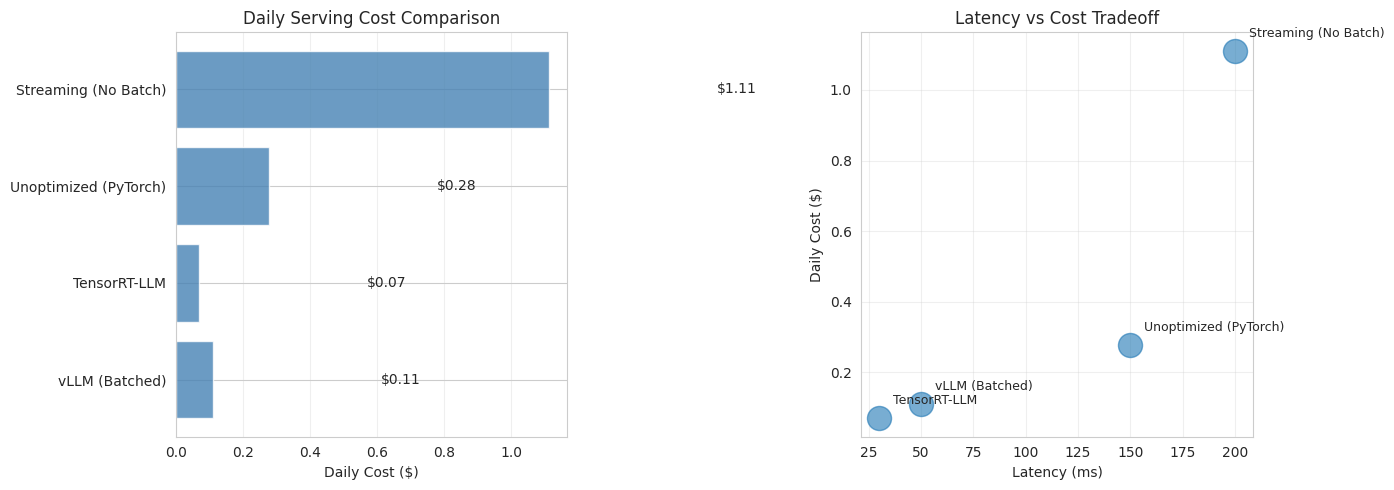

In [9]:
# Cost analysis for different serving approaches
# Assumptions: GPU cost $2/hour, 1 request = 100 tokens

gpu_cost_per_hour = 2.0
tokens_per_request = 100
requests_per_day = 10000

serving_options = {
    'vLLM (Batched)': {
        'throughput_tokens_sec': 5000,
        'latency_ms': 50,
        'description': 'Optimized batching with paged attention'
    },
    'TensorRT-LLM': {
        'throughput_tokens_sec': 8000,
        'latency_ms': 30,
        'description': 'Quantized + optimized kernels'
    },
    'Unoptimized (PyTorch)': {
        'throughput_tokens_sec': 2000,
        'latency_ms': 150,
        'description': 'Standard PyTorch inference'
    },
    'Streaming (No Batch)': {
        'throughput_tokens_sec': 500,
        'latency_ms': 200,
        'description': 'Single request at a time'
    }
}

cost_data = []
for name, specs in serving_options.items():
    throughput = specs['throughput_tokens_sec']
    
    # Calculate daily GPU hours needed
    tokens_per_day = requests_per_day * tokens_per_request
    seconds_needed = tokens_per_day / throughput
    hours_needed = seconds_needed / 3600
    daily_cost = hours_needed * gpu_cost_per_hour
    monthly_cost = daily_cost * 30
    
    cost_data.append({
        'Strategy': name,
        'Throughput (tok/s)': throughput,
        'Latency (ms)': specs['latency_ms'],
        'GPU Hours/Day': hours_needed,
        'Daily Cost ($)': daily_cost,
        'Monthly Cost ($)': monthly_cost
    })

cost_df = pd.DataFrame(cost_data)
print("\nCost Analysis (10K requests/day, 100 tokens/request):")
print(cost_df[['Strategy', 'Throughput (tok/s)', 'Latency (ms)', 'Daily Cost ($)', 'Monthly Cost ($)']].to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Daily cost
axes[0].barh(cost_df['Strategy'], cost_df['Daily Cost ($)'], color='steelblue', alpha=0.8)
axes[0].set_xlabel('Daily Cost ($)')
axes[0].set_title('Daily Serving Cost Comparison')
axes[0].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(cost_df['Daily Cost ($)']):
    axes[0].text(v + 0.5, i, f'${v:.2f}', va='center')

# Latency vs Cost
axes[1].scatter(cost_df['Latency (ms)'], cost_df['Daily Cost ($)'], s=300, alpha=0.6)
for idx, row in cost_df.iterrows():
    axes[1].annotate(row['Strategy'], (row['Latency (ms)'], row['Daily Cost ($)']),
                    xytext=(10, 10), textcoords='offset points', fontsize=9)
axes[1].set_xlabel('Latency (ms)')
axes[1].set_ylabel('Daily Cost ($)')
axes[1].set_title('Latency vs Cost Tradeoff')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Summary: Key Optimization Techniques

In [10]:
summary_table = {
    'Technique': [
        'Quantization',
        'KV-Cache',
        'Speculative Decoding',
        'Batching',
        'Paged Attention',
        'Flash Attention',
        'Model Pruning',
        'Distillation'
    ],
    'Memory Reduction': [
        '2-8x',
        'Varies',
        '0x',
        'Varies',
        '2-4x',
        '1x',
        '2-10x',
        '2-4x'
    ],
    'Latency Impact': [
        '+5-10%',
        '-60-70%',
        '-20-30%',
        'Increases',
        '-40-50%',
        '-20-30%',
        'Varies',
        '+10-20%'
    ],
    'Complexity': [
        'Medium',
        'Low',
        'High',
        'Low',
        'High',
        'Medium',
        'High',
        'High'
    ]
}

summary_df = pd.DataFrame(summary_table)
print("\n" + "="*80)
print("LLM INFERENCE OPTIMIZATION TECHNIQUES")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)


LLM INFERENCE OPTIMIZATION TECHNIQUES
           Technique Memory Reduction Latency Impact Complexity
        Quantization             2-8x         +5-10%     Medium
            KV-Cache           Varies        -60-70%        Low
Speculative Decoding               0x        -20-30%       High
            Batching           Varies      Increases        Low
     Paged Attention             2-4x        -40-50%       High
     Flash Attention               1x        -20-30%     Medium
       Model Pruning            2-10x         Varies       High
        Distillation             2-4x        +10-20%       High


---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>